# 1.3 Tensors and Folding

To further motivate shapes that can be indexed by ND coordinates in addition to 1D coordinates, we generalize observations made in [8] mapping tensor contractions to canonical BLAS-like primitives.

In this work, tensors are denoted by bold letters, indices by lowercase letters, and the bounds of those indices by their corresponding uppercase letters. The rank of a tensor refers to the number of dimensions, also known as modes, it possesses. For example:

- A scalar, $\alpha$, is a rank-0 tensor.
- A vector, $a_i$, is a rank-1 tensor with $0 \le i < I$.
- A matrix, $A_{mn}$ is a rank-2 tensor with $0 \le m < M$ and $0 \le n < N$.
- A three-way array, $A_{mnp}$, is a rank-3 tensor with $0 \le m < M$, $0 \le n < N$, and $0 \le p < P$.

Summation is implied over repeated indices that appear only on a single side of an equation (Einstein notation), so an instance of a tensor contraction is

$$C_{stqp} = A_{stupr} B_{qtru},$$

which represents the contraction of a rank-5 tensor with a rank-4 tensor to produce a rank-4 tensor. Contractions of this form are expressed compactly in the `numpy.einsum` and `torch.einsum` interfaces, for instance.

The above tensor contraction can be rewritten as

$$C_{(sp)(q)(t)} = A_{(sp)(ur)(t)} B_{(q)(ur)(t)},$$

where the modes of the original tensor contraction have been grouped into four types:

- **Row modes, $\hat{m}$**: Appear in A and C, and not in B.
- **Column modes, $\hat{n}$**: Appear in B and C, and not in A.
- **Reduction modes, $\hat{k}$**: Appear in A and B, and not in C.
- **Batch modes, $\hat{\ell}$**: Appear in A, B, and C.

This is referred to as *tensor folding*. Folding a tensor need not require any explicit copy, but can instead simply be a change of view of the data.

In [1]:
import numpy as np

# Demonstrate tensor folding with numpy.einsum
# C_{stqp} = A_{stupr} B_{qtru}
S, T, U, P, R, Q = 2, 3, 4, 2, 3, 5

A = np.random.randn(S, T, U, P, R)
B = np.random.randn(Q, T, R, U)
C = np.einsum('stupr,qtru->stqp', A, B)

print(f"A shape: {A.shape}  (rank-5, indices s,t,u,p,r)")
print(f"B shape: {B.shape}  (rank-4, indices q,t,r,u)")
print(f"C shape: {C.shape}  (rank-4, indices s,t,q,p)")

# Identify mode types:
# Row modes (m-hat):  s, p — in A and C, not in B
# Col modes (n-hat):  q   — in B and C, not in A
# Red modes (k-hat):  u, r — in A and B, not in C
# Batch modes (l-hat): t   — in A, B, and C
print("\nMode classification:")
print(f"  Row (m-hat):       s, p  =>  folded size = {S*P}")
print(f"  Column (n-hat):    q     =>  folded size = {Q}")
print(f"  Reduction (k-hat): u, r  =>  folded size = {U*R}")
print(f"  Batch (l-hat):     t     =>  folded size = {T}")

A shape: (2, 3, 4, 2, 3)  (rank-5, indices s,t,u,p,r)
B shape: (5, 3, 3, 4)  (rank-4, indices q,t,r,u)
C shape: (2, 3, 5, 2)  (rank-4, indices s,t,q,p)

Mode classification:
  Row (m-hat):       s, p  =>  folded size = 4
  Column (n-hat):    q     =>  folded size = 5
  Reduction (k-hat): u, r  =>  folded size = 12
  Batch (l-hat):     t     =>  folded size = 3


As an explicit example of tensor folding, consider the $2 \times 2 \times 2$ tensor of 8 elements shown in the first row of Figure 1. The flat representation holds a shape and a stride for each mode of the tensor to index into the physical data. The flat representation is identical to the representation that is adopted by `std::mdspan` in C++, `torch.tensor` in PyTorch, `numpy.ndarray` in NumPy, among many other similar libraries. The $2 \times 2 \times 2$ tensor can be folded into a $4 \times 2$ matrix by folding the third mode into the first, as shown in the second row. The result admits the flat representation with a shape of $(4, 2)$ and a stride of $(2, 1)$. In principle, the $2 \times 2 \times 2$ tensor can also be folded into a $2 \times 4$ matrix by folding the third mode into the second mode. However, the result no longer admits a flat representation — there is no integer that can represent the stride of the second mode.

In [2]:
from tensor_layouts import Layout, size, rank, depth, mode
from tensor_layouts.viz import draw_layout

# Physical data: a, b, c, d, e, f, g, h at offsets 0..7
data = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

# Rank-3 tensor: Shape (2, 2, 2), Stride (2, 1, 4)
tensor_3d = Layout((2, 2, 2), (2, 1, 4))
print(f"Rank-3 tensor: {tensor_3d}")
print(f"  rank={rank(tensor_3d)}, size={size(tensor_3d)}")
print()

# Show the mapping from (m, n, p) coordinates to physical offsets
print("(m, n, p) -> offset -> data")
for p in range(2):
    for n in range(2):
        for m in range(2):
            offset = tensor_3d(m, n, p)
            print(f"  ({m}, {n}, {p}) -> {offset} -> {data[offset]}")

Rank-3 tensor: (2, 2, 2) : (2, 1, 4)
  rank=3, size=8

(m, n, p) -> offset -> data
  (0, 0, 0) -> 0 -> a
  (1, 0, 0) -> 2 -> c
  (0, 1, 0) -> 1 -> b
  (1, 1, 0) -> 3 -> d
  (0, 0, 1) -> 4 -> e
  (1, 0, 1) -> 6 -> g
  (0, 1, 1) -> 5 -> f
  (1, 1, 1) -> 7 -> h


In [3]:
# Matrix, 4x2: Fold mode 2 into mode 0
# Flat representation: Shape (4, 2), Stride (2, 1)
matrix_4x2_flat = Layout((4, 2), (2, 1))

# CuTe representation: Shape ((2, 2), 2), Stride ((2, 4), 1)
matrix_4x2_cute = Layout(((2, 2), 2), ((2, 4), 1))

print(f"4x2 matrix (flat):  {matrix_4x2_flat}")
print(f"4x2 matrix (CuTe):  {matrix_4x2_cute}")
print()

# Both access the same data in the same order
print("Flat indexing:")
for j in range(2):
    row = [data[matrix_4x2_flat(i, j)] for i in range(4)]
    print(f"  col {j}: {row}")

print("\nCuTe indexing (1D coordinates on mode 0):")
for j in range(2):
    row = [data[matrix_4x2_cute(i, j)] for i in range(4)]
    print(f"  col {j}: {row}")

# Verify they produce the same offsets
assert all(matrix_4x2_flat(i, j) == matrix_4x2_cute(i, j)
           for i in range(4) for j in range(2))
print("\nFlat and CuTe representations agree on all offsets.")

4x2 matrix (flat):  (4, 2) : (2, 1)
4x2 matrix (CuTe):  ((2, 2), 2) : ((2, 4), 1)

Flat indexing:
  col 0: ['a', 'c', 'e', 'g']
  col 1: ['b', 'd', 'f', 'h']

CuTe indexing (1D coordinates on mode 0):
  col 0: ['a', 'c', 'e', 'g']
  col 1: ['b', 'd', 'f', 'h']

Flat and CuTe representations agree on all offsets.


In [4]:
# Matrix, 2x4: Fold mode 2 into mode 1
# Flat representation FAILS: Shape (2, 4), Stride (2, ?) — no single integer works
# Let's see why:
print("Why flat representation fails for 2x4 folding:")
print("We need stride d such that for j=0,1,2,3:")
print("  j=0 -> offset 0, j=1 -> offset 1, j=2 -> offset 4, j=3 -> offset 5")
print("  But 1*d=1 implies d=1, while 2*d=4 implies d=2. Contradiction!")
print()

# CuTe representation: Shape (2, (2, 2)), Stride (2, (1, 4))
matrix_2x4_cute = Layout((2, (2, 2)), (2, (1, 4)))
print(f"2x4 matrix (CuTe): {matrix_2x4_cute}")
print()

# Show the mapping
print("CuTe indexing (1D coordinates on mode 1):")
for i in range(2):
    row = [data[matrix_2x4_cute(i, j)] for j in range(4)]
    print(f"  row {i}: {row}")

# Verify this is the same data as the rank-3 tensor, just viewed differently
# Original tensor: (m, n, p) with shape (2,2,2), stride (2,1,4)
# 2x4 fold: row = m, col = (n, p)  i.e. col j encodes (n, p) = (j%2, j//2)
for i in range(2):
    for j in range(4):
        n, p = j % 2, j // 2
        assert matrix_2x4_cute(i, j) == tensor_3d(i, n, p)
print("\n2x4 CuTe view matches original rank-3 tensor.")

Why flat representation fails for 2x4 folding:
We need stride d such that for j=0,1,2,3:
  j=0 -> offset 0, j=1 -> offset 1, j=2 -> offset 4, j=3 -> offset 5
  But 1*d=1 implies d=1, while 2*d=4 implies d=2. Contradiction!

2x4 matrix (CuTe): (2, (2, 2)) : (2, (1, 4))

CuTe indexing (1D coordinates on mode 1):
  row 0: ['a', 'b', 'e', 'f']
  row 1: ['c', 'd', 'g', 'h']

2x4 CuTe view matches original rank-3 tensor.


Physical data (1D, 8 contiguous elements)


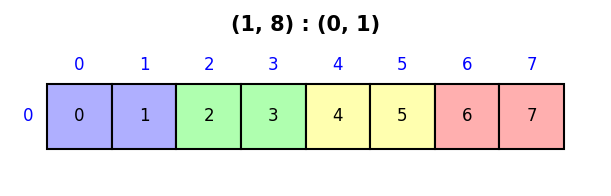


Rank-3 tensor (2,2,2):(2,1,4)


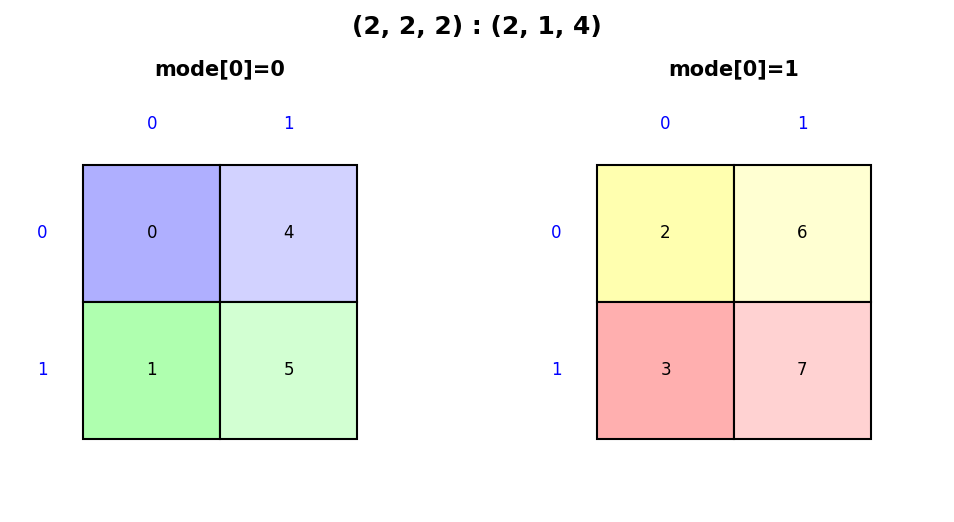


4x2 matrix — fold mode 2 into 0: ((2,2),2):((2,4),1)


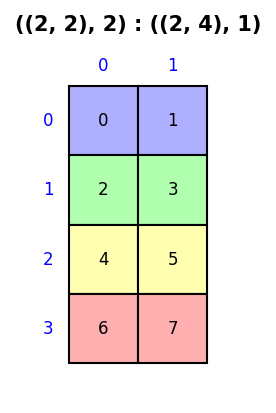


2x4 matrix — fold mode 2 into 1: (2,(2,2)):(2,(1,4))


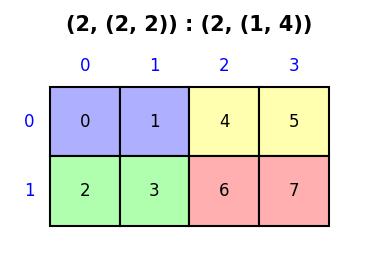

In [5]:
# Visualize all views. We use color_layout to group each pair of adjacent
# physical elements (offsets 0-1, 2-3, 4-5, 6-7) with the same color,
# matching Figure 1 in the paper. color_layout computes offset // 2.

print("Physical data (1D, 8 contiguous elements)")
draw_layout(Layout((1, 8), (0, 1)), colorize=True,
            color_layout=Layout((1, (2, 4)), (0, (0, 1))), num_colors=4)

print("\nRank-3 tensor (2,2,2):(2,1,4)")
draw_layout(tensor_3d, colorize=True)

print("\n4x2 matrix — fold mode 2 into 0: ((2,2),2):((2,4),1)")
draw_layout(matrix_4x2_cute, colorize=True,
            color_layout=Layout(((2, 2), 2), ((1, 2), 0)), num_colors=4)

print("\n2x4 matrix — fold mode 2 into 1: (2,(2,2)):(2,(1,4))")
draw_layout(matrix_2x4_cute, colorize=True,
            color_layout=Layout((2, (2, 2)), (1, (0, 2))), num_colors=4)

The CuTe representation of the folded matrices emphasizes that the tensor folding really is just grouping modes together. In the case of the $4 \times 2$ matrix, the flat representation is called the *coalesced* version of the CuTe representation, while in the case of the $2 \times 4$ matrix no such flat representation exists.

This generalized form of tensor folding allows all tensor contractions to be written in a single canonical contraction form,

$$C_{\hat{m}\hat{n}\hat{\ell}} = A_{\hat{m}\hat{k}\hat{\ell}} B_{\hat{n}\hat{k}\hat{\ell}}.$$

where each mode may be a single mode or a group of modes, which we call a *multi-mode*. Appealing to the canonical loops in Section 1.2, regardless of whether the shape of $\hat{m}$ is $M$ or $(M_0, M_1)$, we can loop over it with 1D coordinates, $m$. Thus, any tensor contraction can be folded into a canonical batched-GEMM and evaluated with a trivial reference implementation composed of four nested loops:

```c
for (int l = 0; l < L; ++l)
    for (int m = 0; m < M; ++m)
        for (int n = 0; n < N; ++n)
            for (int k = 0; k < K; ++k)
                C(m,n,l) += A(m,k,l) * B(n,k,l);
```

In [6]:
# Demonstrate the canonical batched-GEMM using layouts for tensor folding
# Recall: C_{stqp} = A_{stupr} B_{qtru}
# Row (m-hat): s,p    Col (n-hat): q    Red (k-hat): u,r    Batch (l-hat): t

S, T, U, P, R, Q = 2, 3, 4, 2, 3, 5
A = np.random.randn(S, T, U, P, R)
B = np.random.randn(Q, T, R, U)

# Reference: direct einsum
C_ref = np.einsum('stupr,qtru->stqp', A, B)

# Folded views using reshape/transpose
# A_{(sp)(ur)(t)}: shape (S*P, U*R, T)
A_folded = A.transpose(0, 3, 2, 4, 1).reshape(S*P, U*R, T)  # (sp, ur, t)
# B_{(q)(ur)(t)}: shape (Q, U*R, T)
B_folded = B.transpose(0, 3, 2, 1).reshape(Q, U*R, T)  # (q, ur, t)

M_size, K_size, L_size, N_size = S*P, U*R, T, Q
print(f"Folded dimensions: M={M_size}, N={N_size}, K={K_size}, L={L_size}")

# Canonical batched-GEMM with four nested loops
C_gemm = np.zeros((M_size, N_size, L_size))
for l in range(L_size):
    for m in range(M_size):
        for n in range(N_size):
            for k in range(K_size):
                C_gemm[m, n, l] += A_folded[m, k, l] * B_folded[n, k, l]

# Unfold result back: C_{(sp)(q)(t)} -> C_{stqp}
C_unfolded = C_gemm.reshape(S, P, Q, T).transpose(0, 3, 2, 1)

assert np.allclose(C_ref, C_unfolded)
print("Canonical batched-GEMM matches direct einsum!")

Folded dimensions: M=4, N=5, K=12, L=3
Canonical batched-GEMM matches direct einsum!


This simple implementation of batched-GEMM can be used to evaluate a wide range of compatible tensor contractions, including any matrix-multiplication (GEMM), tensor contraction (GETT), and convolution (CONV), with intelligent construction of folded layouts. See Section 2.6.2 for details on generic GEMM and its applications.

Optimizations can then focus on loop reordering, tiling, vectorization, and other common optimizations by transforming the order and rank of the loop nests. These transformations, it turns out, can very often be represented by layouts as permutations on the coordinates spaces of the algorithm. These transform layouts functionally compose with the data layouts to generate new loop nests that are guaranteed to be consistent with the original problem. See Section 3.3 for details on layout composition and application to generic partitioning.